In [1]:
import pandas as pd
import numpy as np

#########################
######   TASK 1   #######
#      read in data     #
#########################

# Read in count file 
file_path = "Data/rsem.merged.gene_counts_2021.tsv"
count_table = pd.read_csv(file_path, sep='\t', index_col=0)

count_table = count_table.drop('transcript_id(s)', axis=1)
# Get an overview of the file
print(count_table.head())

          Naive_EZH2i_R1  Naive_EZH2i_R2  Naive_EZH2i_R3  Naive_R1  Naive_R2  \
gene_id                                                                        
A1BG                 3.0             4.0             6.0       2.0       0.0   
A1BG-AS1             7.0             4.0             5.0       2.0       3.0   
A1CF                 0.0             0.0             0.0       0.0       0.0   
A2M                  1.0             1.0             1.0       0.0       0.0   
A2M-AS1              0.0             0.0             0.0       0.0       0.0   

          Naive_R3  Primed_EZH2i_R1  Primed_EZH2i_R2  Primed_EZH2i_R3  \
gene_id                                                                 
A1BG           4.0            137.0            175.0            143.0   
A1BG-AS1       2.0             36.0             28.0             28.0   
A1CF           0.0              2.0              0.0              0.0   
A2M            0.0            143.0            114.0            112.0   
A

In [2]:
# Read in clinical data file / annotation 
file_path_cl = "Data/metaData.csv"

# Read in file 
clinical_data = pd.read_csv(file_path_cl, sep=",")

# Get an overview of the file
print(clinical_data.head())

      BioSample          SRR       condition              treatment  \
0  SAMN25076933  SRR17657871  naive (t2iGoY)                   none   
1  SAMN25076934  SRR17657872  naive (t2iGoY)                   none   
2  SAMN25076935  SRR17657873  naive (t2iGoY)                   none   
3  SAMN25076936  SRR17657874  naive (t2iGoY)  10 uM EZH2 for 7 days   
4  SAMN25076938  SRR17657875  naive (t2iGoY)  10 uM EZH2 for 7 days   

             Name  
0        Naive_R1  
1        Naive_R2  
2        Naive_R3  
3  Naive_EZH2i_R1  
4  Naive_EZH2i_R2  


In [3]:
#########################
######   TASK 2   #######
# Preparation for DESeq #
#########################

# prepare count table 
# filter for lowly expressed genes
genes_to_keep = count_table.columns[count_table.sum(axis=0) >= 10]
counts_df = count_table[genes_to_keep]

# convert dataframe to integer
counts_df = counts_df.astype(int)

# transpose dataframe for Deseq analysis
counts_df = counts_df.T

counts_df.head()

gene_id,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Naive_EZH2i_R1,3,7,0,1,0,10,0,0,317,0,...,81,137,12,53,89,38,116,919,186,106
Naive_EZH2i_R2,4,4,0,1,0,10,0,0,303,0,...,101,135,10,34,107,34,99,865,192,94
Naive_EZH2i_R3,6,5,0,1,0,16,0,0,279,0,...,95,146,7,39,99,37,115,767,204,107
Naive_R1,2,2,0,0,0,7,0,0,1072,0,...,158,235,15,146,150,213,144,1193,332,199
Naive_R2,0,3,0,0,0,6,0,0,1045,0,...,133,229,19,147,176,233,137,1093,306,173


In [4]:
# prepare metaData


# filter clinical data for naive samples
filtered_clinical = clinical_data[clinical_data["condition"].str.contains("naive", case=False, na=False)]

# shape meta for DESeq analysis (name as index, treatment as column)
meta = filtered_clinical.set_index("Name")
meta = meta[["treatment"]]
print(meta)

# get naive samples only and filter count table 
naive_samples = meta.index
print(naive_samples)

count_naive = count_table[naive_samples]
count_naive = count_naive.astype(int)
count_naive = count_naive[~count_naive.index.duplicated(keep="first")]
count_naive


                            treatment
Name                                 
Naive_R1                         none
Naive_R2                         none
Naive_R3                         none
Naive_EZH2i_R1  10 uM EZH2 for 7 days
Naive_EZH2i_R2  10 uM EZH2 for 7 days
Naive_EZH2i_R3  10 uM EZH2 for 7 days
Index(['Naive_R1', 'Naive_R2', 'Naive_R3', 'Naive_EZH2i_R1', 'Naive_EZH2i_R2',
       'Naive_EZH2i_R3'],
      dtype='str', name='Name')


,Naive_R1,Naive_R2,Naive_R3,Naive_EZH2i_R1,Naive_EZH2i_R2,Naive_EZH2i_R3
gene_id,,,,,,
A1BG,2,0,4,3,4,6
A1BG-AS1,2,3,2,7,4,5
A1CF,0,0,0,0,0,0
A2M,0,0,0,1,1,1
A2M-AS1,0,0,0,0,0,0
...,...,...,...,...,...,...
ZYG11A,213,233,214,38,34,37
ZYG11B,144,137,124,116,99,115
ZYX,1193,1093,1346,919,865,767


In [5]:
#########################
######   TASK 3   #######
#     Running DESeq2    #
#########################

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DeseqDataSet
dds = DeseqDataSet(
    counts=count_naive.T,
    metadata=meta,
    design="~treatment",
    refit_cooks=True)


In [6]:
# run dds.deseq2()
dds.deseq2()

Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 4.06 seconds.

Fitting dispersion trend curve...
... done in 0.68 seconds.

Fitting MAP dispersions...
... done in 4.27 seconds.

Fitting LFCs...
... done in 2.66 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 0 outlier genes.



In [14]:
print(dds.obsm["design_matrix"].columns)



Index(['Intercept', 'treatment[T.none]'], dtype='str')


In [26]:
# calculate DESeqStats and summary
ds = DeseqStats(dds, contrast=["treatment", "10 uM EZH2 for 7 days", "none"],n_cpus=1)
# get ds summary overview

print(ds.summary())


Running Wald tests...


Log2 fold change & Wald test p-value: treatment 10 uM EZH2 for 7 days vs none
             baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_id                                                                    
A1BG         3.385463        1.627342  1.100441   1.478810  1.391912e-01   
A1BG-AS1     4.128906        1.701937  0.961602   1.769897  7.674429e-02   
A1CF         0.000000             NaN       NaN        NaN           NaN   
A2M          0.591524        2.952533  2.895528   1.019687  3.078769e-01   
A2M-AS1      0.000000             NaN       NaN        NaN           NaN   
...               ...             ...       ...        ...           ...   
ZYG11A     112.932390       -2.088826  0.207422 -10.070422  7.465713e-24   
ZYG11B     121.141407        0.214549  0.176296   1.216983  2.236108e-01   
ZYX       1005.964972        0.001137  0.090122   0.012611  9.899382e-01   
ZZEF1      251.495668       -0.253481  0.126225  -2.008171  4.462511e-02   
ZZZ3      

... done in 3.75 seconds.



In [ ]:
ds.lfc_shrink(coeff="treatment[T.none]")
print(ds.summary())


KeyError: "The coeff argument 'treatment[T.10 uM EZH2 for 7 days]' should be one the LFC columns. The available LFC coeffs are Index(['treatment[T.none]'], dtype='str')."

In [15]:
#########################
######   TASK 4   #######
#    volcanoe plot      #
#########################

# get results in object
res = ds.results_df
res_sorted = res.sort_values(by="padj")
print(res_sorted)


                baseMean  log2FoldChange     lfcSE       stat    pvalue  padj
gene_id                                                                      
IGFBP3        876.172760       -5.216714  0.132781  39.310171  0.000000   0.0
COL1A2       3008.467372       -3.037534  0.060393  50.337722  0.000000   0.0
COL6A2       2184.715219       -3.051502  0.069617  43.883122  0.000000   0.0
COL6A1       3512.899380       -2.413743  0.060179  40.161719  0.000000   0.0
COL4A2       2063.172371       -3.022237  0.069686  43.419472  0.000000   0.0
...                  ...             ...       ...        ...       ...   ...
ZSCAN1          0.693945        0.204465  1.570728  -0.922042  0.356507   NaN
ZSCAN16-AS1     1.754305        0.056530  0.830389  -0.211113  0.832799   NaN
ZSCAN23         0.745381        0.109269  1.079268  -0.569065  0.569312   NaN
ZSCAN5B         1.138501       -0.011815  0.862651   0.053819  0.957079   NaN
ZSWIM2          0.000000             NaN       NaN        NaN   

In [16]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# genes to mark as in volcanoe plot
genes_to_mark =  ["KRT18",  "H19", "IGF2", "EPAS2", "COL6A3", "MME",
    "VIM", "MMP2", "EGFL6", "CCKBR", "GATA2", "COL15A1", "CD99","EPAS1",
    "LAMB1", "THBD", "FRZB",  "RELN", "TDGF1", "MT1G","DDPA5","NODAL","NANOG","UTF1",
    "FGF4"]



# create volcanoe_df for plotting
volcanoe_df = res_sorted.copy()

# remove possible missing values and filter for log2FC and padj
volcanoe_df = volcanoe_df.dropna(subset=["log2FoldChange", "padj"])


# replace "0" padj and calculate -log10
volcanoe_df["padj"] = volcanoe_df["padj"].replace(0, 1e-300)
volcanoe_df["neg_log10_padj"] = -np.log10(volcanoe_df["padj"])


# read in color mapping (groups of genes)
file_path = "Data/gene_group_mapping.csv"
color_annotation = pd.read_csv(file_path, sep=',', index_col=0)

# colors similar to figure 
color_map = {
    "Always_up": "navy",
    "Ni_higher_than_Pr": "#008B8B",
    "Pr_higher_than_Ni": "#A52A2A"
}


# delete duplicated entries in volcanoe_df and color_annotation
volcanoe_df = volcanoe_df[~volcanoe_df.index.duplicated(keep="first")]
color_annotation = color_annotation[~color_annotation.index.duplicated(keep="first")]

# map group and color to volcanoe_dj
volcanoe_df["group"] = color_annotation["group"].reindex(volcanoe_df.index)
volcanoe_df["color"] = volcanoe_df["group"].map(color_map)

# set all other colors to darkgrey
volcanoe_df["color"] = volcanoe_df["color"].fillna("darkgrey")

# get subsets of data sets for plotting
subsetNon = volcanoe_df[volcanoe_df["group"] == "Non bivalent"]
subsetUp = volcanoe_df[volcanoe_df["group"] == "Always_up"]
subsetNi = volcanoe_df[volcanoe_df["group"] == "Ni_higher_than_Pr"]
subsetPr = volcanoe_df[volcanoe_df["group"] == "Pr_higher_than_Ni"]

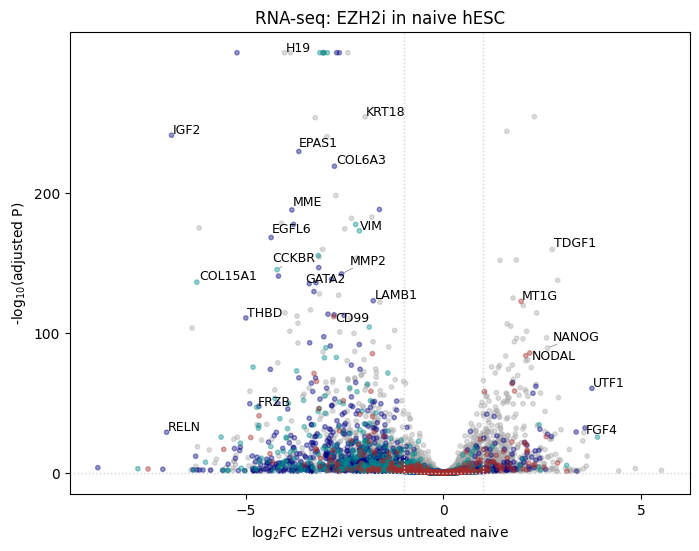

In [17]:

plt.figure(figsize=(8,6))

# background
plt.scatter(
    subsetNon["log2FoldChange"],
    subsetNon["neg_log10_padj"],
    s=10,
    color=subsetNon["color"],
    alpha=0.4,
    zorder=0
)

# blue points
plt.scatter(
    subsetUp["log2FoldChange"],
    subsetUp["neg_log10_padj"],
    s=10,
    color=subsetUp["color"],
    alpha=0.4,
    zorder=0
)


# cyan points
plt.scatter(
    subsetNi["log2FoldChange"],
    subsetNi["neg_log10_padj"],
    s=10,
    color=subsetNi["color"],
    alpha=0.4,
    zorder=0
)


# red points
plt.scatter(
    subsetPr["log2FoldChange"],
    subsetPr["neg_log10_padj"],
    s=10,
    color=subsetPr["color"],
    alpha=0.4,
    zorder=0
)

# get texts for each gene to mark
texts = []
for gene in genes_to_mark:
    if gene in volcanoe_df.index:
        x = volcanoe_df.loc[gene, "log2FoldChange"]
        y = volcanoe_df.loc[gene, "neg_log10_padj"]

        texts.append(
            plt.text(x, y, gene, fontsize=9)
        )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

plt.xlabel(r"log$_2$FC EZH2i versus untreated naive")
plt.ylabel(r"-log$_{10}$(adjusted P)")
plt.title("RNA-seq: EZH2i in naive hESC")
plt.xticks([-5,0,5])
plt.yticks([0,100,200])
plt.axhline(y=0, color="lightgrey", linestyle=":", linewidth=1)
plt.axvline(x=-1, color="lightgrey", linestyle=":", linewidth=1)
plt.axvline(x=1, color="lightgrey", linestyle=":", linewidth=1)
plt.show()